✅ Added domain_length column (95856 valid rows)
✅ nonchit dataframe created: 41902 rows
✅ chit dataframe created: 53954 rows


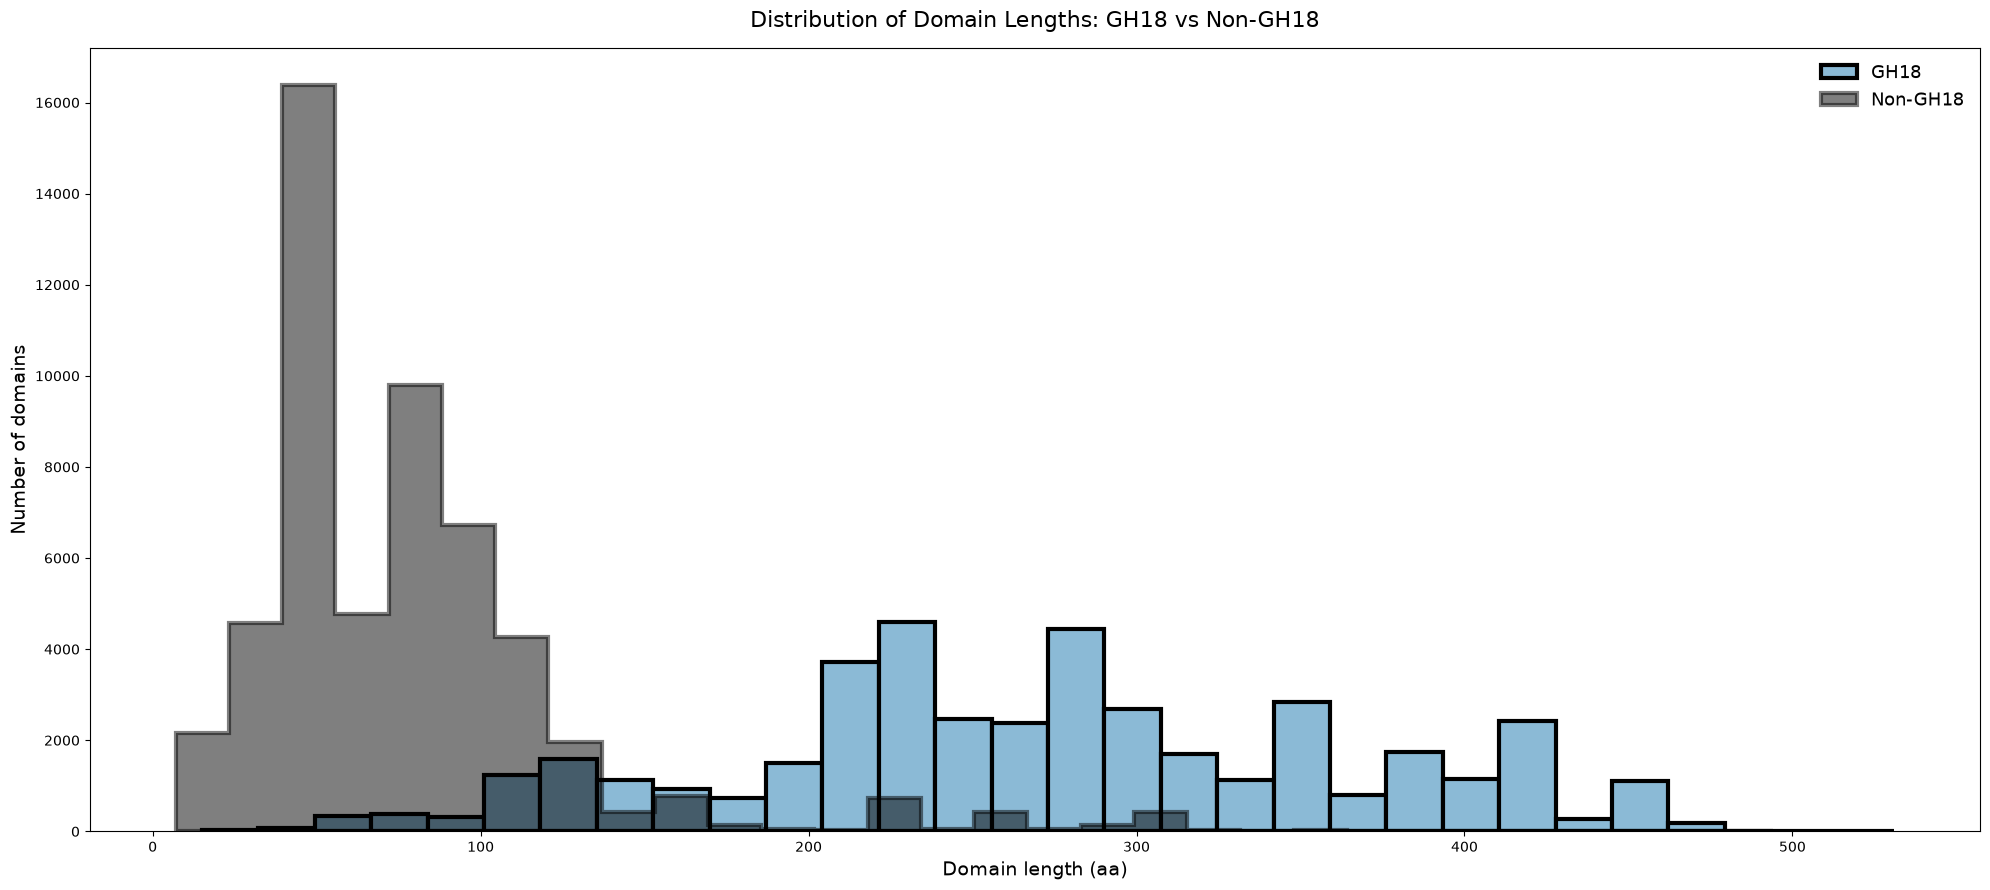

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/annotation/all_domains_annotated_deduplicated_cleaned.tsv', sep='\t')

# Ensure start and end are numeric
df["start"] = pd.to_numeric(df["start"], errors="coerce")
df["end"] = pd.to_numeric(df["end"], errors="coerce")

# Compute domain length (inclusive coordinates)
df["domain_length"] = df["end"] - df["start"] + 1
print(f"✅ Added domain_length column ({df['domain_length'].notna().sum()} valid rows)")

# Split into GH18 and non-GH18 sets
nonchit = df[df["GH18_ID"].notna()].copy()
chit = df[df["GH18_ID"].isna()].copy()

print(f"✅ nonchit dataframe created: {len(nonchit)} rows")
print(f"✅ chit dataframe created: {len(chit)} rows")

# --- Combined stacked histogram with hatch pattern for GH18 ---
plt.figure(figsize=(20, 9))

# Plot non-GH18 as filled grey
plt.hist(
    nonchit["domain_length"],
    bins=30,
    color="#8bbad6",
    edgecolor="black",
    linewidth=3,
    label="GH18",
)

# Overlay GH18 as black-and-white hatched bars
plt.hist(
    chit["domain_length"],
    bins=30,
    histtype="stepfilled",
    color="black",
    edgecolor="black",
    linewidth=3,
    #hatch="/   /",      # diagonal hatching
    alpha=0.5,
    label="Non-GH18",
)

plt.grid(False)
plt.xlabel("Domain length (aa)", fontsize=14)
plt.ylabel("Number of domains", fontsize=14)
plt.title("Distribution of Domain Lengths: GH18 vs Non-GH18", fontsize=16, pad=15)
plt.legend(frameon=False, fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/domain_length_histogram_GH18_striped_blackwhite_1.png", dpi=600)
plt.show()


statistical test - does follow exponential decay?

In [22]:
#chitinase dataset with rows were Total_num_GH18domains is not Nan
df = pd.read_csv('../data/annotation/all_domains_annotated_deduplicated_cleaned.tsv', sep='\t') 

chitinase_df = df[df["Total_num_GH18domains"].notna()]
chitinase_df = chitinase_df.drop_duplicates(subset='protein_accession')
chitinase_df

,protein_accession,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start,end,score,status,...,end_num,score_num,span,priority_rank,sig_freq_global,Total_num_GH18domains,GH18domain_num,GH18sequence,fastaID,GH18_ID
0,A0A010YG22,BCAC65E13E44ACC0D5889A40D5B1A2F8,354,PROSITE profiles,PS51910,Glycosyl hydrolases family 18 (GH18) domain pr...,56,354,1.020352e+01,T,...,354.0,1.020352e+01,299,2.0,39036,1.0,1.0,YAPYVYVTLADRPSLTEIAQKTGANGLHLGFAITKGDECDLTWDGT...,A0A010YG22|1of1,True
1,A0A011PM39,2B03A5B39A2C5137BCACBC4D01697D06,1156,Pfam,PF00704,Glycosyl hydrolases family 18,137,428,2.300000e-16,T,...,428.0,2.300000e-16,292,1.0,36361,2.0,1.0,AFFVNWDDASMSSLKENLGSLDTVIAEWLHLASEDGTLRENDPLRT...,A0A011PM39|1of2,True
5,A0A011PXQ4,BCAE3BD21D067344C874DD0EB6344E16,1156,Pfam,PF00704,Glycosyl hydrolases family 18,136,428,2.200000e-16,T,...,428.0,2.200000e-16,293,1.0,36361,2.0,1.0,IGFFVNWDDASMSSLKENLGSLDTVIAEWLHLASEDGTLRENDPLR...,A0A011PXQ4|1of2,True
10,A0A014LJM1,8495312E26224E3E1925B2F1461C43E6,344,PROSITE profiles,PS51910,Glycosyl hydrolases family 18 (GH18) domain pr...,56,344,1.060503e+01,T,...,344.0,1.060503e+01,289,2.0,39036,1.0,1.0,AAVAPYLYNGWGNPPDPGEVMDATGVGWFTLAFVLDAGNCDPRWDG...,A0A014LJM1|1of1,True
11,A0A014LR51,9F864E95FB4997720FE7F921ECFB6456,336,Pfam,PF00704,Glycosyl hydrolases family 18,51,270,3.600000e-14,T,...,270.0,3.600000e-14,220,1.0,36361,1.0,1.0,VTGYWQNFDNGATKQKLSDVPDDYDIIAVAFADATGTPGAVDFKLD...,A0A014LR51|1of1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95846,X6Q4Q0,83C4D5DBFD8A1179D0BA7A5552A33164,1132,Pfam,PF00704,Glycosyl hydrolases family 18,196,410,1.500000e-19,T,...,410.0,1.500000e-19,215,1.0,36361,2.0,1.0,AIGRIMRDEKKRMALINEMVGTCRRYGFVGINLDLEELNIQDNDLL...,X6Q4Q0|1of2,True
95851,X8GPF2,70D3A80C4982E83860FD2DA40F7823CA,567,Pfam,PF00704,Glycosyl hydrolases family 18,334,554,2.100000e-20,T,...,554.0,2.100000e-20,221,1.0,36361,1.0,1.0,KTVLNTTSARDNLVNGLIAAAIRYNLDGINVDIESLPTEAADGYIQ...,X8GPF2|1of1,True
95852,X8HE75,A456F3A5EAF449088DBE76505D69FC5A,539,Pfam,PF00704,Glycosyl hydrolases family 18,206,422,2.900000e-19,T,...,422.0,2.900000e-19,217,1.0,36361,1.0,1.0,ILADEAVWKKYAQNLIQYAYIYGFDGYNFDFENVDYSDRDKLTRFV...,X8HE75|1of1,True
95853,Z9JN00,A28869D690FF03DAD30FDC1D4D83035F,351,Pfam,PF00704,Glycosyl hydrolases family 18,37,336,1.000000e-21,T,...,336.0,1.000000e-21,300,1.0,36361,1.0,1.0,NSFLAHADKIDTLVPTWYSVDPKGLVNGAPNERIYRIAQKKKITVT...,Z9JN00|1of1,True


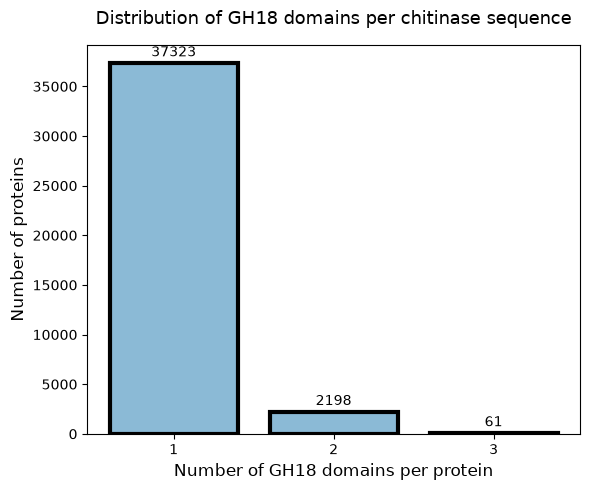

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure correct column type
chitinase_df["Total_num_GH18domains"] = pd.to_numeric(
    chitinase_df["Total_num_GH18domains"], errors="coerce"
)

# Get one entry per protein
domain_counts = (
    chitinase_df[["protein_accession", "Total_num_GH18domains"]]
    .drop_duplicates(subset=["protein_accession"])
)

# Count occurrences of each domain count
counts = domain_counts["Total_num_GH18domains"].value_counts().sort_index()

# --- Plot ---
plt.figure(figsize=(6, 5))
bars = plt.bar(
    counts.index.astype(int),
    counts.values,
    color="#8bbad6",      # bone shade
    edgecolor="black",
    linewidth=3,
    width=0.8
)

# Annotate bar heights
for p in bars:
    plt.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + max(counts.values) * 0.01,
        f"{int(p.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10
    )

#no gridlines
plt.grid(False)

plt.xlabel("Number of GH18 domains per protein", fontsize=12)
plt.ylabel("Number of proteins", fontsize=12)
plt.title("Distribution of GH18 domains per chitinase sequence", fontsize=13, pad=15)
#sns.despine()
#
plt.xticks(counts.index.astype(int))
plt.tight_layout()
plt.savefig('../results/figures/domain_architecture_distribution_GH18_chitinases_blue_black_notext.png', dpi=600)
plt.show()


adjustments for reviewer 2

In [24]:
mast = pd.read_csv('../data/annotation/singleseq_perline_masterannot_allseq_taxasp_39582_260805_260925.csv')
assert mast['domains'].notna().all(), "NaN in domains column"
domain_counts = pd.Series(
    mast['domains'].str.split().apply(len).to_numpy(),   # .split() not .split(' ')
    index=mast['Entry'],                                  # <-- the missing piece
    name='k')
assert domain_counts.index.is_unique, "duplicate Entry values"
domain_counts

Entry
A0A010YG22    1
A0A011PM39    3
A0A011PXQ4    3
A0A014LJM1    2
A0A014LR51    1
             ..
X6Q4Q0        3
X8GPF2        2
X8HE75        1
Z9JN00        1
Z9JR83        2
Name: k, Length: 39582, dtype: int64

In [25]:
#domain_counts.to_csv('domain_counts_per_protein_accession.csv', index=True, header=True)

N = 39,582 sequences   mean domains = 2.37

        null      w  k=1 fold  k=2 fold  k=3 fold  k=4 fold
 exponential  1.254      0.50      1.10      3.86      3.12
   geometric  0.434      0.79      1.00      2.02      0.93
     poisson 66.172      1.31      0.70      1.19      0.70

Headline claim = k=1 fold < 1 (deficit) AND k=3 fold > 1 (excess) under
ALL nulls -> robust to null choice. Report w + folds, NOT z=120.



,k,Observed,p_obs,p_exponential,fold_exponential,p_geometric,fold_geometric,p_poisson,fold_poisson
0,1,13139,0.3319,0.6681,0.50,0.4220,0.79,0.2542,1.310000e+00
1,2,9633,0.2434,0.2218,1.10,0.2439,1.00,0.3482,7.000000e-01
2,3,11257,0.2844,0.0736,3.86,0.1410,2.02,0.2384,1.190000e+00
3,4,3015,0.0762,0.0244,3.12,0.0815,0.93,0.1088,7.000000e-01
4,5,1057,0.0267,0.0081,3.29,0.0471,0.57,0.0373,7.200000e-01
5,6,677,0.0171,0.0027,6.35,0.0272,0.63,0.0102,1.680000e+00
6,7,522,0.0132,0.0009,14.76,0.0157,0.84,0.0023,5.660000e+00
7,8,169,0.0043,0.0003,14.39,0.0091,0.47,0.0005,9.360000e+00
8,9,39,0.0010,0.0001,10.01,0.0053,0.19,0.0001,1.262000e+01
9,10,25,0.0006,0.0000,19.32,0.0030,0.21,0.0000,5.317000e+01



 ident  N_clust  mean_k  k1 fixed  k3 fixed |  k1 refit  k3 refit  w refit
  full    39582    2.37      0.79      2.02 |         -         -        -
  0.90    20711    2.27      0.89      1.82 |      0.85      1.86    0.365
  0.70    10880    2.17      1.03      1.48 |      0.94      1.55    0.240
  0.50     4987    2.06      1.20      1.04 |      1.04      1.15    0.169
  0.40     3250    2.04      1.26      0.88 |      1.07      1.01    0.151
  0.30     2366    2.09      1.26      0.92 |      1.09      0.96    0.157

Read-off: k3 fixed -> ~1 means the excess vanishes once redundancy
is removed. k3 refit -> ~1 means it's gone even against a null matched
to the dereplicated mean (i.e. a genuine shape change, not just a shift).


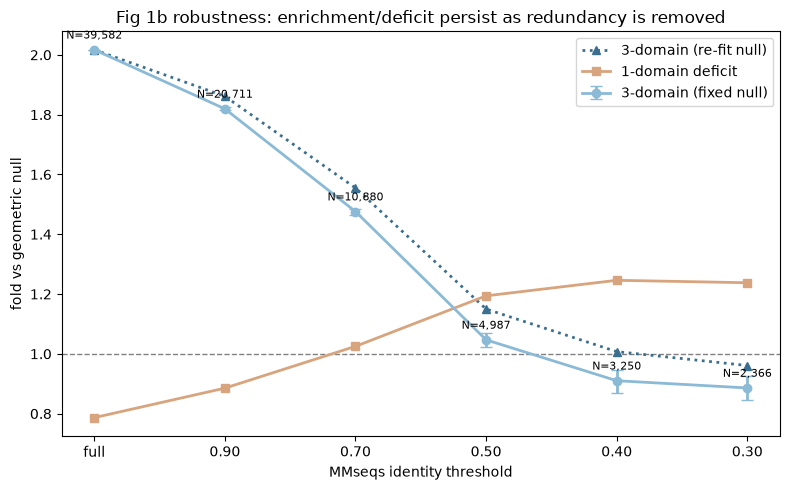

In [26]:
# ============================================================================
# NEW CELL  —  paste after your exponential-decay cell.
# Effect sizes (not N-inflated chi2) + multi-null robustness + MMseqs derep sweep
# Reuses `domain_counts` (index = protein_accession, value = n domains) from
# your existing cell. Only ### EDIT line required: the FASTA to cluster.
# ============================================================================
import os, subprocess, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG = np.random.default_rng(0)

# ---------------------------------------------------------------------------
# 0. Observed domain-count distribution (per protein), support 1..K
# ---------------------------------------------------------------------------
counts = domain_counts.to_numpy()                 # one value per protein_accession
counts = counts[counts > 0]
N, K   = counts.size, int(counts.max())
ks     = np.arange(1, K + 1)
O      = np.array([(counts == k).sum() for k in ks], float)
p_obs  = O / N
mean_k = counts.mean()

# ---------------------------------------------------------------------------
# 1. NULL MODELS  (each a probability over k>=1, renormalised on the support)
#    Same "random accretion" idea, different gain/loss rules -> different shape.
# ---------------------------------------------------------------------------
# (a) EXPONENTIAL — your existing fit: lambda = -log(p1), decay from k=1
p1      = O[0] / N
lam_exp = -np.log(p1)
p_exp   = np.exp(-lam_exp * (ks - 1)); p_exp /= p_exp.sum()

# (b) GEOMETRIC — memoryless: constant gain + constant loss; MLE on the mean
q       = 1 - 1 / mean_k
p_geom  = (1 - q) * q ** (ks - 1); p_geom /= p_geom.sum()

# (c) POISSON (shifted to k>=1) — constant gain + loss proportional to # domains
p_pois  = stats.poisson.pmf(ks - 1, mean_k - 1); p_pois /= p_pois.sum()

# (d) EMPIRICAL PROTEOME BACKGROUND — the cleanest null. Provide a 2-col csv
#     (k, p) from a genome-wide InterProScan / your refs 38-39; else skipped.
try:
    bg   = pd.read_csv("proteome_background_domaincounts.csv")     ### EDIT (optional)
    p_bg = np.interp(ks, bg["k"], bg["p"], left=0, right=0); p_bg /= p_bg.sum()
except FileNotFoundError:
    p_bg = None

NULLS = [("exponential", p_exp), ("geometric", p_geom), ("poisson", p_pois)]
if p_bg is not None: NULLS.append(("background", p_bg))

# ---------------------------------------------------------------------------
# 2. EFFECT SIZES — the actual evidence, independent of N
#    Cohen's w = sqrt(sum (p_obs-p_exp)^2 / p_exp);  note chi2 = N * w^2
# ---------------------------------------------------------------------------
def cohen_w(p_o, p_e):
    m = p_e > 0
    return np.sqrt(np.sum((p_o[m] - p_e[m]) ** 2 / p_e[m]))

print(f"N = {N:,} sequences   mean domains = {mean_k:.2f}\n")
print(f"{'null':>12} {'w':>6} {'k=1 fold':>9} {'k=2 fold':>9} {'k=3 fold':>9} {'k=4 fold':>9}")
for name, pe in NULLS:
    fold = p_obs / pe
    print(f"{name:>12} {cohen_w(p_obs, pe):>6.3f} "
          f"{fold[0]:>9.2f} {fold[1]:>9.2f} {fold[2]:>9.2f} "
          f"{(fold[3] if K>=4 else np.nan):>9.2f}")
print("\nHeadline claim = k=1 fold < 1 (deficit) AND k=3 fold > 1 (excess) under\n"
      "ALL nulls -> robust to null choice. Report w + folds, NOT z=120.\n")

# full observed-vs-expected table (kept for the paper / SI)
eff = pd.DataFrame({"k": ks, "Observed": O.astype(int), "p_obs": p_obs.round(4)})
for name, pe in NULLS:
    eff[f"p_{name}"]    = pe.round(4)
    eff[f"fold_{name}"] = (p_obs / pe).round(2)
display(eff)

# ---------------------------------------------------------------------------
# 3. MMseqs DEREPLICATION SWEEP
#    --cluster-mode 0  = greedy SET-COVER (representative = most connected).
#    (Longest-as-representative is --cluster-mode 2; we deliberately avoid it.)
# ---------------------------------------------------------------------------
FASTA   = "../data/annotation/full_seq_39582seqs.fasta"     ### EDIT: FASTA whose headers start with protein_accession
                                   #   (full-length proteins = redundancy by whole-protein
                                   #    similarity; GH18-domain-only = by catalytic marker.
                                   #    Full-length is the usual redundancy-reduction choice.)
THRESH  = [0.90, 0.70, 0.50, 0.40, 0.30]
WORKDIR = "../data/annotation/mmseqs_derep"; os.makedirs(WORKDIR, exist_ok=True)
dom_by_id = domain_counts.to_dict()

def mmseqs_cluster(fasta, min_id, prefix):
    """Return path to *_cluster.tsv (rep<TAB>member). Set-cover, not longest."""
    tmp = os.path.join(WORKDIR, f"tmp_{prefix}")
    out = os.path.join(WORKDIR, prefix)
    subprocess.run(
        ["mmseqs", "easy-cluster", fasta, out, tmp,
         "--min-seq-id", str(min_id),
         "-c", "0.8", "--cov-mode", "0",     # 80% bidirectional coverage
         "--cluster-mode", "0",              # set-cover representative
         "-s", "7.5",                        # high sensitivity for low identity
         "-v", "1"],
        check=True)
    return out + "_cluster.tsv"

def geom_from_mean(vec):
    """Geometric null RE-FIT to this vector's own mean. Separates a *shift*
    in the distribution (mean moves under dereplication) from a change in
    *shape* (is it still non-geometric AT its own mean?)."""
    mk = vec.mean(); qq = 1 - 1 / mk
    pg = (1 - qq) * qq ** (ks - 1); return pg / pg.sum()

def _folds(vec, null):
    Ov = np.array([(vec == k).sum() for k in ks], float); pv = Ov / Ov.sum()
    return pv[0]/null[0], (pv[2]/null[2] if K>=3 else np.nan), cohen_w(pv, null)

def sweep(cluster_tsv, fixed_null=p_geom, n_boot=200):
    m = pd.read_csv(cluster_tsv, sep="\t", header=None, names=["rep", "member"])
    m["k"] = m["member"].map(dom_by_id)
    m = m.dropna(subset=["k"])
    n_clusters = m["rep"].nunique()
    rep_k  = m.drop_duplicates("rep").set_index("rep")["k"].to_numpy()
    groups = [g["k"].to_numpy() for _, g in m.groupby("rep")]
    # representative-set point estimates: fixed null AND re-fit null
    rep_fixed = _folds(rep_k, fixed_null)
    rep_refit = _folds(rep_k, geom_from_mean(rep_k))
    # random-member bootstrap: fixed AND re-fit
    bf1, bf3, bfw, br1, br3, brw, mns = [], [], [], [], [], [], []
    for _ in range(n_boot):
        pk = np.array([RNG.choice(g) for g in groups])
        f = _folds(pk, fixed_null);          bf1.append(f[0]); bf3.append(f[1]); bfw.append(f[2])
        r = _folds(pk, geom_from_mean(pk));   br1.append(r[0]); br3.append(r[1]); brw.append(r[2])
        mns.append(pk.mean())
    return dict(n_clusters=n_clusters, mean=float(np.mean(mns)),
                rep_fixed=rep_fixed, rep_refit=rep_refit,
                rand_fixed=(np.array(bf1), np.array(bf3), np.array(bfw)),
                rand_refit=(np.array(br1), np.array(br3), np.array(brw)))

# --- run it (comment out if FASTA not ready yet) ---
sweep_res = {}
if os.path.exists(FASTA):
    for thr in THRESH:
        tsv = mmseqs_cluster(FASTA, thr, f"id{int(thr*100)}")
        sweep_res[thr] = sweep(tsv)
    # FIXED null = full-data geometric (mean 2.40). RE-FIT null = geometric at
    # each dereplicated set's own mean. If k3(refit) also ~1, the 3-domain
    # excess is a redundancy artefact, not just a distributional shift.
    print(f"\n{'ident':>6} {'N_clust':>8} {'mean_k':>7} "
          f"{'k1 fixed':>9} {'k3 fixed':>9} | {'k1 refit':>9} {'k3 refit':>9} {'w refit':>8}")
    print(f"{'full':>6} {N:>8} {mean_k:>7.2f} "
          f"{p_obs[0]/p_geom[0]:>9.2f} {p_obs[2]/p_geom[2]:>9.2f} | "
          f"{'-':>9} {'-':>9} {'-':>8}")
    for thr in THRESH:
        r = sweep_res[thr]
        rf1 = np.median(r['rand_refit'][0]); rf3 = np.median(r['rand_refit'][1])
        rw  = np.median(r['rand_refit'][2])
        print(f"{thr:>6.2f} {r['n_clusters']:>8} {r['mean']:>7.2f} "
              f"{r['rep_fixed'][0]:>9.2f} {r['rep_fixed'][1]:>9.2f} | "
              f"{rf1:>9.2f} {rf3:>9.2f} {rw:>8.3f}")
    print("\nRead-off: k3 fixed -> ~1 means the excess vanishes once redundancy\n"
          "is removed. k3 refit -> ~1 means it's gone even against a null matched\n"
          "to the dereplicated mean (i.e. a genuine shape change, not just a shift).")
else:
    print(f"\n[note] FASTA '{FASTA}' not found — set the path to run the sweep.")

# ---------------------------------------------------------------------------
# 4. ROBUSTNESS FIGURE — folds vs identity threshold (the rebuttal money shot)
# ---------------------------------------------------------------------------
if sweep_res:
    xs = ["full"] + [f"{t:.2f}" for t in THRESH]
    k3 = [p_obs[2]/p_geom[2]] + [np.median(sweep_res[t]["rand_fixed"][1]) for t in THRESH]
    k1 = [p_obs[0]/p_geom[0]] + [np.median(sweep_res[t]["rand_fixed"][0]) for t in THRESH]
    k3r = [p_obs[2]/p_geom[2]] + [np.median(sweep_res[t]["rand_refit"][1]) for t in THRESH]
    k3lo = [0] + [np.median(sweep_res[t]["rand_fixed"][1]) - np.percentile(sweep_res[t]["rand_fixed"][1], 2.5) for t in THRESH]
    k3hi = [0] + [np.percentile(sweep_res[t]["rand_fixed"][1], 97.5) - np.median(sweep_res[t]["rand_fixed"][1]) for t in THRESH]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axhline(1, color="grey", ls="--", lw=1)
    ax.errorbar(xs, k3, yerr=[k3lo, k3hi], marker="o", color="#8bbad6", lw=2,
                capsize=4, label="3-domain (fixed null)")
    ax.plot(xs, k3r, marker="^", color="#3a6f8f", lw=2, ls=":", label="3-domain (re-fit null)")
    ax.plot(xs, k1, marker="s", color="#D8A47D", lw=2, label="1-domain deficit")
    for x, t in zip(xs, ["full"] + THRESH):
        n = N if t == "full" else sweep_res[t]["n_clusters"]
        ax.annotate(f"N={n:,}", (x, k3[xs.index(x)]), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xlabel("MMseqs identity threshold"); ax.set_ylabel("fold vs geometric null")
    ax.set_title("Fig 1b robustness: enrichment/deficit persist as redundancy is removed")
    ax.legend(); plt.tight_layout()
    plt.savefig("../results/figures/fig1b_dereplication_robustness.png", dpi=600); plt.show()

taxa analysis

[warn] 1516 sequences missing phylum; excluded from taxon views.

Taxon-annotated sequences: 38,066  |  >=3-domain: 16,656 (43.8% of all)

Multi-domain contribution by phylum (phyla with >=0.5% of the 3+ pool)
  pct_multi_pool = share of all >=3-domain sequences
  pct_all_seqs   = share of all taxon-annotated sequences  <- denominator
  pct_within_tax = % of that taxon's sequences with >=3 domains (dataset base rate 43.8%)
  ratio          = pct_multi_pool / pct_all_seqs;  >1 enriched, <1 depleted

                   n_all  n_multi  pct_multi_pool  pct_all_seqs  pct_within_tax  ratio  mean_k
phylum                                                                                        
Bacillota          10222     5630            33.8          26.9            55.1   1.26    2.56
Actinomycetota     12791     4994            30.0          33.6            39.0   0.89    2.17
Pseudomonadota      7143     3422            20.5          18.8            47.9   1.09    2.89
Bacteroidota        3

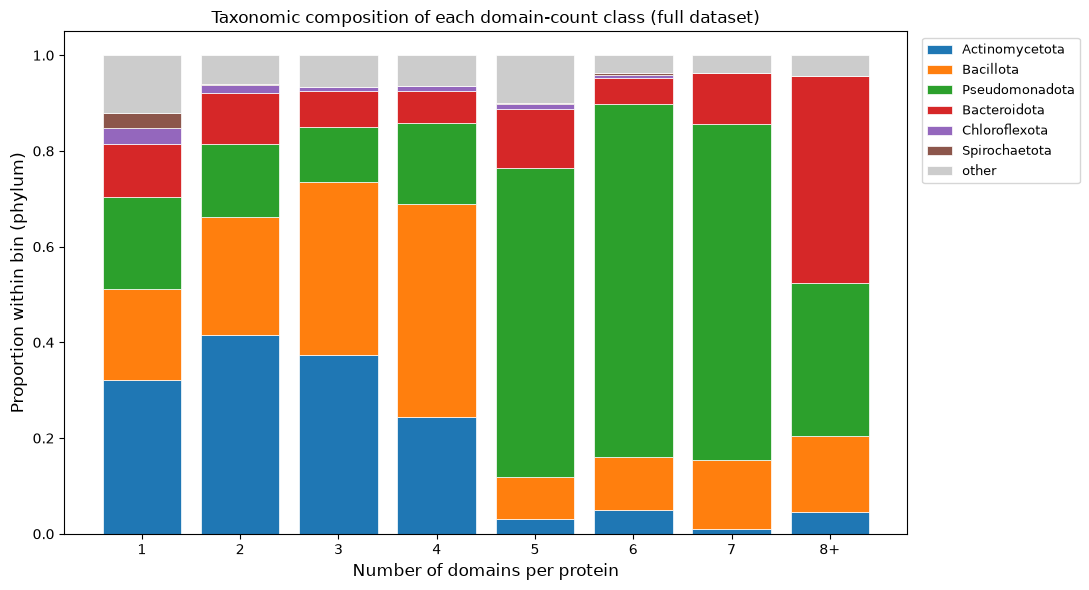

In [27]:
# ============================================================================
# NEXT CELL — where does the multi-domain inflation come from?
# Diagnoses which taxa (a) dominate the 3+ domain pool and (b) collapse most
# under dereplication. If one clade drives both, the Fig 1b "excess" is that
# clade's lineage-specific expansion, not a family-wide property.
#
# Needs a taxonomy table (you already have this from the Fig 4 work):
#   columns: protein_accession, phylum, genus
# Reuses `domain_counts`, `dom_by_id`, `ks` and mmseqs_derep/*_cluster.tsv.
# ============================================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

### EDIT: taxonomy file. Must contain protein_accession + phylum (+ genus).
tax = pd.read_csv("../data/annotation/singleseq_perline_masterannot_allseq_taxasp_39582_260805_260925.csv")
tax['protein_accession'] = tax['Entry']
tax = tax.drop_duplicates("protein_accession") \
        .set_index("protein_accession")

LEVEL = "phylum"          # set to "genus" for the finer culprit (e.g. Streptomyces)

# attach domain counts to taxonomy
dc = domain_counts.rename("k").to_frame().join(tax, how="left")
n_missing = dc[LEVEL].isna().sum()
if n_missing:
    print(f"[warn] {n_missing} sequences missing {LEVEL}; excluded from taxon views.\n")
dc = dc.dropna(subset=[LEVEL])

# ---------------------------------------------------------------------------
# 1. Who contributes the 3+ domain sequences — WITH the denominator.
#    share_multi alone confounds propensity with abundance; ratio separates them.
# ---------------------------------------------------------------------------
MULTI = 3 #dc["k"] == 3                                   # "multi-domain" = k >= MULTI
n_all_tot   = len(dc)
n_multi_tot = (dc["k"] >= MULTI).sum()
base_rate   = 100 * n_multi_tot / n_all_tot

g = dc.groupby(LEVEL)
tx = pd.DataFrame({
    "n_all":   g.size(),
    "n_multi": g["k"].apply(lambda s: (s >= MULTI).sum()),
})
tx["pct_all_seqs"]   = 100 * tx["n_all"]   / n_all_tot        # <- the denominator
tx["pct_multi_pool"] = 100 * tx["n_multi"] / n_multi_tot      # your old "share"
tx["pct_within_tax"] = 100 * tx["n_multi"] / tx["n_all"]      # propensity
tx["ratio"]          = tx["pct_multi_pool"] / tx["pct_all_seqs"]
tx["mean_k"]         = g["k"].mean()

tx = tx.sort_values("pct_multi_pool", ascending=False)
show = tx[tx["pct_multi_pool"] >= 0.5]                        # manuscript cutoff

print(f"Taxon-annotated sequences: {n_all_tot:,}  |  >={MULTI}-domain: {n_multi_tot:,} "
      f"({base_rate:.1f}% of all)\n")
print(f"Multi-domain contribution by {LEVEL} (phyla with >=0.5% of the {MULTI}+ pool)")
print("  pct_multi_pool = share of all >=3-domain sequences")
print("  pct_all_seqs   = share of all taxon-annotated sequences  <- denominator")
print(f"  pct_within_tax = % of that taxon's sequences with >={MULTI} domains "
      f"(dataset base rate {base_rate:.1f}%)")
print("  ratio          = pct_multi_pool / pct_all_seqs;  >1 enriched, <1 depleted\n")
print(show[["n_all", "n_multi", "pct_multi_pool", "pct_all_seqs",
            "pct_within_tax", "ratio", "mean_k"]]
      .round({"pct_multi_pool": 1, "pct_all_seqs": 1, "pct_within_tax": 1,
              "ratio": 2, "mean_k": 2}).to_string(), "\n")
print(f"[check] listed phyla cover {show['n_all'].sum()/n_all_tot:.1%} of annotated sequences "
      f"and {show['n_multi'].sum()/n_multi_tot:.1%} of the {MULTI}+ pool\n")
# ---------------------------------------------------------------------------
# 2. Redundancy per taxon at 70% identity: collapse = n_seqs / n_clusters
#    (high collapse = heavily oversampled / low-diversity clade)
# ---------------------------------------------------------------------------
tsv = "../data/annotation/mmseqs_derep/id70_cluster.tsv"
if os.path.exists(tsv):
    m = pd.read_csv(tsv, sep="\t", header=None, names=["rep", "member"])
    m["tax"] = m["member"].map(tax[LEVEL])
    red = m.dropna(subset=["tax"]).groupby("tax").agg(
        n_seqs=("member", "nunique"), n_clusters=("rep", "nunique"))
    red["collapse"] = (red["n_seqs"] / red["n_clusters"]).round(1)
    red = red[red["n_seqs"] >= 50]           # ignore tiny taxa
    red = red.join(tx["n_all"], how="left")
    print("[check] cluster-tsv n_seqs vs taxonomy n_all (should match):")
    print(red[["n_seqs", "n_all"]].head(10).to_string(), "\n")
    print(f"Most redundant taxa at 70% id (collapse = seqs/clusters), n_seqs>=50:")
    print(red.sort_values("collapse", ascending=False).head(10).to_string(), "\n")
else:
    print(f"[note] {tsv} not found — run the sweep cell first.\n")

# ---------------------------------------------------------------------------
# 3. Leave-one-taxon-out: does the 3-domain excess survive removing the
#    dominant taxon?  (fold vs a geometric RE-FIT to each subset's own mean)
# ---------------------------------------------------------------------------
def k3_fold_refit(kvec):
    kvec = np.asarray(kvec, float)
    p  = np.array([(kvec == k).mean() for k in ks])
    mk = kvec.mean(); q = 1 - 1/mk
    pg = (1 - q) * q ** (ks - 1); pg /= pg.sum()
    return p[2] / pg[2]

#top = share.index[0]
top = tx.index[0]
print(f"{'removed':>20} {'n_left':>8} {'mean_k':>7} {'k3 fold':>8} {'delta':>7}")
base = k3_fold_refit(dc["k"])
print(f"{'(none)':>20} {len(dc):>8,} {dc['k'].mean():>7.2f} {base:>8.2f} {'-':>7}")
for t in show.index[:5]:
    sub = dc[dc[LEVEL] != t]
    f = k3_fold_refit(sub["k"])
    print(f"{t:>20} {len(sub):>8,} {sub['k'].mean():>7.2f} {f:>8.2f} {f-base:>+7.2f}")
print(f"k=3 fold (full, re-fit null):        {k3_fold_refit(dc['k']):.2f}")
print(f"k=3 fold (excluding {top}): {k3_fold_refit(dc[dc[LEVEL]!=top]['k']):.2f}")
print("If the excess collapses toward 1 when the top clade is removed, the\n"
      "Fig 1b signal is that clade's lineage-specific architecture, not family-wide.\n")

# ---------------------------------------------------------------------------
# 4. VISUAL — taxonomic composition of each domain-count bin (1..7, 8+)
#    Shows directly whether the 3-4 domain bins are one-clade-dominated.
# ---------------------------------------------------------------------------
KMAX = 8
kx = np.arange(1, KMAX + 1)
topn = dc[LEVEL].value_counts().head(6).index.tolist()
dc["tax_grp"] = np.where(dc[LEVEL].isin(topn), dc[LEVEL], "other")
binlab = [str(k) for k in kx[:-1]] + [f"{KMAX}+"]
comp = np.zeros((len(topn) + 1, KMAX))
grps = topn + ["other"]
for j, k in enumerate(kx):
    sub = dc[dc["k"] == k] if k < KMAX else dc[dc["k"] >= KMAX]
    vc = sub["tax_grp"].value_counts(normalize=True)
    for i, g in enumerate(grps):
        comp[i, j] = vc.get(g, 0.0)

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(KMAX)
cmap = plt.get_cmap("tab10")
for i, g in enumerate(grps):
    ax.bar(binlab, comp[i], bottom=bottom, label=g,
           color=("#cccccc" if g == "other" else cmap(i)), edgecolor="white", lw=0.5)
    bottom += comp[i]
ax.set_xlabel("Number of domains per protein", fontsize=12)
ax.set_ylabel(f"Proportion within bin ({LEVEL})", fontsize=12)
ax.set_title("Taxonomic composition of each domain-count class (full dataset)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../results/figures/fig1b_taxon_composition_by_domaincount_1.png", dpi=600)
plt.show()

updated cell with new analysis and figure output

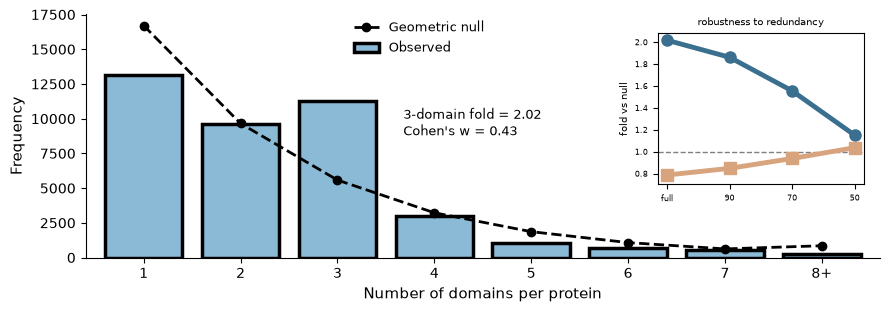

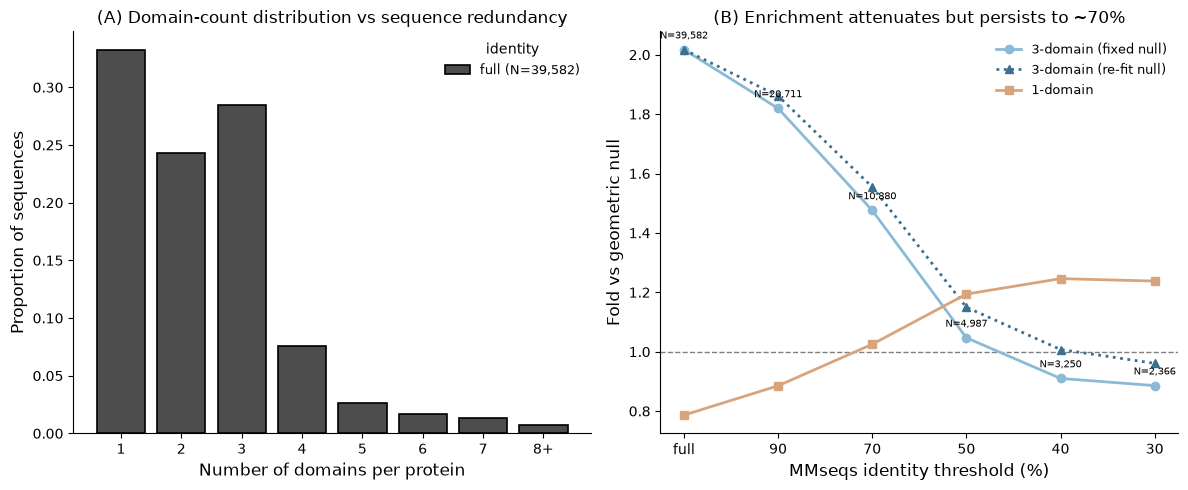

In [28]:
# ============================================================================
# NEXT CELL — rebuilt Fig 1b (main) + SI robustness figure.
# Uses objects from the sweep cell: p_obs, p_geom, O, N, sweep_res, dom_by_id.
# Keeps your house style: bars #8bbad6, black edge, lw 3, width 0.8.
# ============================================================================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

KMAX = 8                                   # bars 1..7 exact, last bar = "8+"
kx   = np.arange(1, KMAX + 1)
BLUE, TAN, PUR, DARK = "#8bbad6", "#D8A47D", "#B08BA2", "#3a6f8f"

# collapse the tail into an "8+" bin so no mass is hidden
def to_bins(p_full):
    p = list(p_full[:KMAX - 1]); p.append(float(np.sum(p_full[KMAX - 1:])))
    return np.array(p)

obs_bins  = to_bins(p_obs)                 # observed proportions
geom_bins = to_bins(p_geom)                # geometric-null proportions
obs_cnt   = obs_bins * N                   # -> counts (your panel is in counts)
geom_cnt  = geom_bins * N
xticklab  = [str(k) for k in kx[:-1]] + [f"{KMAX}+"]

# ============================ MAIN Fig 1b ===================================
# Native aspect ratio matched to the placement box so lines/markers don't
# distort when you rescale in Illustrator. W:H = 332.529 : 119.239 (~2.79:1).
ASPECT   = 332.529 / 119.239
FIG_W    = 9.0
FIG_H    = FIG_W / ASPECT                  # ~3.23 in
SHOW_INSET = True                          # set False to rely on the SI panel

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.bar(kx, obs_cnt, color=BLUE, edgecolor="black", linewidth=2.5, width=0.8,
       label="Observed", zorder=2)
ax.plot(kx, geom_cnt, "o--", color="black", markersize=6, linewidth=2,
        label="Geometric null", zorder=3)

ax.set_xlabel("Number of domains per protein", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_xticks(kx); ax.set_xticklabels(xticklab)
ax.set_xlim(0.4, KMAX + 0.6)
ax.legend(loc="upper center", bbox_to_anchor=(0.42, 1.02), frameon=False, fontsize=9)
for s in ("top", "right"): ax.spines[s].set_visible(False)

# effect-size annotation (the numbers that replace chi2/z)
w_geom = np.sqrt(np.nansum((p_obs - p_geom) ** 2 / np.where(p_geom > 0, p_geom, np.nan)))
ax.text(0.40, 0.62, f"3-domain fold = {p_obs[2]/p_geom[2]:.2f}\nCohen's w = {w_geom:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9)

# --- inset: 3-domain enrichment is robust to redundancy to ~70% ------------
if SHOW_INSET and sweep_res:
    xin = ["full", "90", "70", "50"]
    thr_in = [0.90, 0.70, 0.50]
    k3 = [p_obs[2]/p_geom[2]] + [np.median(sweep_res[t]["rand_refit"][1]) for t in thr_in]
    lo = [0] + [np.median(sweep_res[t]["rand_refit"][1]) -
                np.percentile(sweep_res[t]["rand_refit"][1], 2.5) for t in thr_in]
    hi = [0] + [np.percentile(sweep_res[t]["rand_refit"][1], 97.5) -
                np.median(sweep_res[t]["rand_refit"][1]) for t in thr_in]
    # 1-domain fold across thresholds (re-fit null): the apparent full-data
    # deficit climbs back toward 1 -> single-domain depletion does NOT survive.
    k1 = [p_obs[0]/p_geom[0]] + [np.median(sweep_res[t]["rand_refit"][0]) for t in thr_in]
    l1 = [0] + [np.median(sweep_res[t]["rand_refit"][0]) -
                np.percentile(sweep_res[t]["rand_refit"][0], 2.5) for t in thr_in]
    h1 = [0] + [np.percentile(sweep_res[t]["rand_refit"][0], 97.5) -
                np.median(sweep_res[t]["rand_refit"][0]) for t in thr_in]
    axin = ax.inset_axes([0.72, 0.30, 0.26, 0.62])
    axin.axhline(1, color="grey", ls="--", lw=1)
    axin.errorbar(xin, k3, yerr=[lo, hi], marker="o", color=DARK, lw=3.5,
                  markersize=8, capsize=2, label="3-domain")
    axin.errorbar(xin, k1, yerr=[l1, h1], marker="s", color=TAN, lw=3.5,
                  markersize=8, capsize=2, label="1-domain")
    axin.set_ylabel("fold vs null", fontsize=7)
    axin.set_title("robustness to redundancy", fontsize=7)
    #axin.legend(fontsize=6, frameon=False, loc="center right")
    axin.tick_params(labelsize=6); axin.set_ylim(0.7, None)

plt.tight_layout()
#plt.savefig("fig1b_main_geometric5.png", dpi=1200, bbox_inches="tight")
plt.show()

# ============================ SI robustness figure ==========================
def rep_props(tsv):
    m = pd.read_csv(tsv, sep="\t", header=None, names=["rep", "member"])
    kk = pd.Series(pd.unique(m["rep"])).map(dom_by_id).dropna().to_numpy()
    p = [(kk == k).mean() for k in kx[:-1]]; p.append((kk >= KMAX).mean())
    return np.array(p), len(kk)

WORKDIR = "mmseqs_derep"
si_sets = {"full": (obs_bins, N)}
for thr, col, in [(90, "id90"), (70, "id70"), (50, "id50")]:
    tsv = os.path.join(WORKDIR, f"{col}_cluster.tsv")
    if os.path.exists(tsv):
        si_sets[f"{thr}%"] = rep_props(tsv)

fig2, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

# (A) grouped histogram: proportion per domain-count for each set
labels = list(si_sets.keys())
palette = {"full": "#4d4d4d", "90%": BLUE, "70%": TAN, "50%": PUR}
width = 0.8 / len(labels); xpos = np.arange(KMAX)
for i, lab in enumerate(labels):
    p, n = si_sets[lab]
    axA.bar(xpos + i * width - 0.4 + width / 2, p, width,
            color=palette.get(lab), edgecolor="black", linewidth=1.2,
            label=f"{lab} (N={n:,})")
axA.set_xticks(xpos); axA.set_xticklabels(xticklab)
axA.set_xlabel("Number of domains per protein", fontsize=12)
axA.set_ylabel("Proportion of sequences", fontsize=12)
axA.set_title("(A) Domain-count distribution vs sequence redundancy")
axA.legend(title="identity", frameon=False, fontsize=9)
for s in ("top", "right"): axA.spines[s].set_visible(False)

# (B) fold vs identity threshold — full sweep, fixed and re-fit nulls
if sweep_res:
    THRESH = sorted(sweep_res.keys(), reverse=True)
    xs = ["full"] + [f"{int(t*100)}" for t in THRESH]
    k3fx = [p_obs[2]/p_geom[2]] + [np.median(sweep_res[t]["rand_fixed"][1]) for t in THRESH]
    k3rf = [p_obs[2]/p_geom[2]] + [np.median(sweep_res[t]["rand_refit"][1]) for t in THRESH]
    k1fx = [p_obs[0]/p_geom[0]] + [np.median(sweep_res[t]["rand_fixed"][0]) for t in THRESH]
    axB.axhline(1, color="grey", ls="--", lw=1)
    axB.plot(xs, k3fx, "o-",  color=BLUE, lw=2, label="3-domain (fixed null)")
    axB.plot(xs, k3rf, "^:",  color=DARK, lw=2, label="3-domain (re-fit null)")
    axB.plot(xs, k1fx, "s-",  color=TAN,  lw=2, label="1-domain")
    for i, x in enumerate(xs):
        n = N if x == "full" else sweep_res[THRESH[i-1]]["n_clusters"]
        axB.annotate(f"N={n:,}", (x, k3fx[i]), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=7)
    axB.set_xlabel("MMseqs identity threshold (%)", fontsize=12)
    axB.set_ylabel("Fold vs geometric null", fontsize=12)
    axB.set_title("(B) Enrichment attenuates but persists to ~70%")
    axB.legend(frameon=False, fontsize=9)
    for s in ("top", "right"): axB.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/figSI_fig1b_robustness3_1.png", dpi=1200, bbox_inches="tight")
plt.show()